In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
water = {
    'molecular_weight':18,
    'density_constants':[17.863, 58.606, -95.396, 213.89, -141.26],
    'vp_constants':[73.649, -7.2582E3, -7.3037, 4.1653E-6, 2],
    'water':1
}

mtbe = {
    'molecular_weight':88.148,
    'density_constants':[0.82988, 0.27143, 497.1, 0.28571],
    'vp_constants':[78.6159, -5.99166E3, -8.48773, 9.63875E-9, 3]
}

acn = {
    'molecular_weight':41.052,
    'density_constants':[1.0693, 0.20656, 565.5, 0.24699],
    'vp_constants':[46.735, -5.12618E3, -3.54064, 1.39951E-17, 6]
}

etac = {
    'molecular_weight':88.105,
    'density_constants':[0.8996, 0.25856, 523.3, 0.278],
    'vp_constants':[66.823, -6.2276E3, -6.41, 1.7914E-17, 6]
}

meoh = {
    'molecular_weight':32.042,
    'density_constants':[2.3267, 0.27073, 512.5, 0.24713],
    'vp_constants':[82.718, -6.9045E3, -8.8622, 7.4664E-6, 2]
}

ipa = {
    'molecular_weight':60.095,
    'density_constants':[1.1799, 0.2644, 508.3, 0.24653],
    'vp_constants':[110.717, -9.04E3, -12.676, 5.538E-6, 2]
}

we can add methods for mass determination
if liquid_mass is none and initial_level is not and total_volume is not -> then initial mass = initial_level*total_volume/spec_vol(T_0)

etc, there could be few combination for it

In [6]:
class Component:

    def __init__(
        self,
        T_0,
        P_0,
        liquid_mass,
        component_json,
        initial_liquid_level,
        nitrogen_mass
    ):

        self.T_0 = T_0
        self.P_0 = P_0
        self.m_s = liquid_mass
        self.m_N = nitrogen_mass
        self.alpha_0 = 1 - initial_liquid_level
        self.component = component_json
        
        self.water = False
        if 'water' in self.component.keys():
            self.water = True

        self.M_N = 28
        self.M_s = self.component["molecular_weight"]
        self.B_dens = self.component["density_constants"]
        self.B_vp = self.component["vp_constants"]

        self.R_N = 8.314 / self.M_N 
        self.R_s = 8.314 / self.M_s
    
    def spec_vol(self, T):

        B = self.B_dens
        
        if self.water:
            T_c = 647.095
            tau = 1 - T / T_c
            _density_kmol_m3 = B[0] + B[1] * tau ** (0.35) + B[2] * tau ** (2/3) + B[3] * tau + B[4] * tau ** (4/3)
        else:
            _density_kmol_m3 = B[0] / B[1] ** ( 1 + ( 1 - T / B[2] ) ** B[3] )
        
        _density_kg_m3 = _density_kmol_m3 * self.M_s
        _spec_vol = 1 / _density_kg_m3

        return _spec_vol

    def vapor_pressure(self, T):

        B = self.B_vp
        ln_P_Pa = B[0] + B[1] / T + B[2] * np.log(T) + B[3] * T ** B[4]
        _P_kPa = np.exp(ln_P_Pa) / 1000
        
        return _P_kPa

    def find_nitrogen_mass_or_alpha(self):
        
        if self.m_N == None:
            self.m_N = self.alpha_0 * self.m_s * self.spec_vol(self.T_0) * self.P_0 / ((1 - self.alpha_0) * self.R_N * self.T_0)
        else:
            self.alpha_0 = 1 / ( 1 + self.m_s * self.spec_vol(self.T_0) * self.P_0 / ( self.m_N * self.R_N * self.T_0 ) )

    def m_v(self, P, T):
        y_v = self.vapor_pressure(T) / P
        mf_v = y_v * self.M_s / ( self.M_N + ( self.M_s - self.M_N ) * y_v )
        _m_v = (1 / ( 1 - mf_v ) - 1 ) * self.m_N
        return _m_v

class Derivatives:

    def __init__(
        self,
        specific_volume_function,
        vapor_mass_function,
        nitrogen_mass,
        liquid_mass,
        R_nitrogen,
        R_liquid
    ):

        self.spec_vol = specific_volume_function
        self.m_v = vapor_mass_function
        self.m_N = nitrogen_mass
        self.m_s = liquid_mass
        self.R_N = R_nitrogen
        self.R_s = R_liquid

    def derivative_T(self, f, T):
        _h = 0.01
        _d = (f(T+_h) - f(T-_h)) / (2 * _h)
        return _d

    def dmv_dT(self, P, T):
        _h = 0.01
        _d = (self.m_v(P, T+_h) - self.m_v(P, T-_h)) / (2 * _h)
        return _d
    
    def dmv_dP(self, P, T):
        _h = 0.01
        _d = (self.m_v(P+_h, T) - self.m_v(P-_h, T)) / (2 * _h)
        return _d
    
    def dv_dT(self, T):
        _dv_dT = self.derivative_T(self.spec_vol, T)
        return _dv_dT

    def dV_dT(self, P, T):

        dV_l_dT = (self.m_s - self.m_v(P, T)) * self.dv_dT(T) - self.spec_vol(T) * self.dmv_dT(P, T)
        dV_v_dT = self.R_s / P * ( self.m_v(P, T) + T * self.dmv_dT(P, T) )
        dV_N_dT = self.m_N * self.R_N / P
        
        _dV_dT = dV_l_dT + dV_v_dT + dV_N_dT

        return _dV_dT

    def dV_dP(self, P, T):

        dV_l_dP = -self.spec_vol(T) * self.dmv_dP(P, T)
        dV_v_dP = self.R_s * T / P * ( self.dmv_dP(P, T) - self.m_v(P, T) / P )
        dV_N_dP = -self.m_N * self.R_N * T / P ** 2

        _dV_dP = dV_l_dP + dV_v_dP + dV_N_dP

        return _dV_dP

    def F(self, P, T):

        _F = -self.dV_dP(P, T) / self.dV_dT(P, T)

        return _F

In [10]:
def find_temperature(T_0, P_0, P_e, max_temp_step, liquid_mass, component_json, initial_level=None, nitrogen_mass=None):

    T_0 += 273.15
    
    comp = Component(T_0, P_0, liquid_mass, component_json, initial_level, nitrogen_mass)
    comp.find_nitrogen_mass_or_alpha()
    der = Derivatives(comp.spec_vol, comp.m_v, comp.m_N, comp.m_s, comp.R_N, comp.R_s)

    # initialize
    P = [P_0]
    T = [T_0]
    mv_list = [comp.m_v(P_0, T_0)]
    F_list = [der.F(P_0, T_0)]
    vp_list = [comp.vapor_pressure(T_0)]

    i=1
    while P[i-1] <= P_e:

        P_i = P[i-1] + max_temp_step / F_list[i-1]
        
        T_i = T[i-1]
        F_i = der.F(P_i, T_i)
        mv_i = comp.m_v(P_i, T_i)
        if mv_i > comp.m_s:
            mv_i = comp.m_s
        
        mv_list.append(mv_i)
        F_list.append(F_i)
        vp_list.append(comp.vapor_pressure(T_i))
        P.append(P_i)
        T.append(T_i + F_i * (P_i - P[i-1]))

        i+=1

    combined_output = np.c_[P, T, vp_list, mv_list, F_list]
    
    profile = pd.DataFrame(combined_output, columns=['pressure', 'temperature', 'vap_pressure', 'm_v', 'F'])
    profile.loc[:, 'liquid_level'] = comp.spec_vol(profile['temperature']) / comp.spec_vol(T_0)*(1 - comp.alpha_0)
    profile.loc[:, 'temperature_C'] = profile['temperature'] - 273.15
    profile.loc[:, 'p_pisg'] = profile['pressure']/100*14.50377-14.21
    
    return profile

In [22]:
w = find_temperature(20, 100, 700, 10, 1000, water, 0.8)

In [23]:
w

,pressure,temperature,vap_pressure,m_v,F,liquid_level,temperature_C,p_pisg
0,100.000000,293.150000,2.339284,0.004442,1.637204,0.800000,20.000000,0.293770
1,106.107975,302.564973,2.339284,0.004181,1.541423,0.802757,29.414973,1.179657
2,112.595487,310.983547,4.107300,0.007021,1.297658,0.805460,37.833547,2.120590
3,120.301675,319.309824,6.574750,0.010721,1.080466,0.808362,46.159824,3.238278
4,129.556938,327.502858,10.182964,0.015819,0.885230,0.811448,54.352858,4.580640
5,140.853441,335.608946,15.277827,0.022562,0.717575,0.814734,62.458946,6.219059
6,154.789266,343.660062,22.320617,0.031247,0.577728,0.818237,70.510062,8.240279
7,172.098452,351.683350,31.874713,0.042154,0.463528,0.821976,78.533350,10.750764
8,193.672131,359.699727,44.626682,0.055525,0.371581,0.825968,86.549727,13.879760
9,220.584141,367.724677,61.401025,0.071531,0.298192,0.830234,94.574677,17.783016


<Axes: xlabel='temperature_C'>

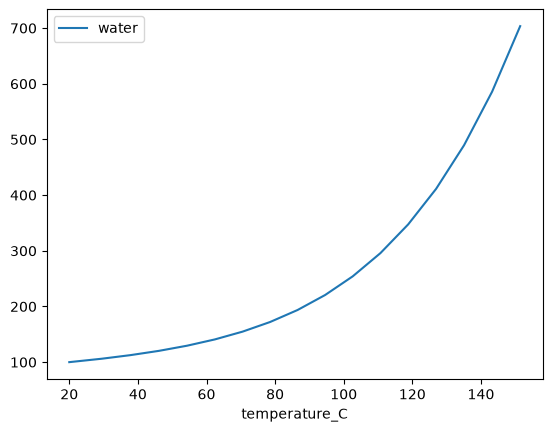

In [24]:
w.plot(x='temperature_C', y='pressure', label='water')